Data Preparation Stage

In [147]:
import pandas as pd
from sklearn import *


Import data and sort by time

In [148]:
df = pd.read_csv("../../Data/CSV/silver_prices_10years.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.head()

,Date,Close,High,Low,Open,Volume
0,2016-01-19,14.110,14.110,14.065,14.065,3
1,2016-01-20,14.147,14.147,14.147,14.147,1
2,2016-01-21,14.083,14.083,14.083,14.083,2
3,2016-01-22,14.043,14.290,14.043,14.290,7
4,2016-01-25,14.240,14.240,14.095,14.095,8


Drop an blank data

In [149]:
df = df.dropna()

Feature: Previous Day Price 7AVG 30AVG 

In [150]:
#Previous Day Price
df['Prev_Close'] = df['Close'].shift(1)

# 7-Day Moving Average
df['MA7'] = df['Close'].rolling(window=7).mean()

# 30-Day Moving Average
df['MA30'] = df['Close'].rolling(window=30).mean()

##lag feature 
df['Lag1'] = df['Close'].shift(1)
df['Lag2'] = df['Close'].shift(2)
df['Lag3'] = df['Close'].shift(3)
df['Lag5'] = df['Close'].shift(5)
df['Lag10'] = df['Close'].shift(10)

# for  more acc
# momantum
df['Return'] = df['Close'].pct_change()
##short term mm
df['MA3'] = df['Close'].rolling(3).mean()
#volaitixxx
df['Volatility'] = df['Close'].rolling(7).std()
df['Return'] = df['Close'].pct_change()
df['Volatility'] = df['Close'].rolling(7).std()

## Drop NA
df = df.dropna()

## Display
print(df[['Prev_Close', 'MA7', 'MA30']].head())

    Prev_Close        MA7       MA30
29      14.896  15.027000  14.845767
30      14.733  15.001857  14.875533
31      15.003  14.987000  14.908333
32      15.131  15.042571  14.961600
33      15.681  15.108000  15.014267


train & test 

In [151]:
# Feature Engineering
df['Prev_Close'] = df['Close'].shift(1)
df['MA7'] = df['Close'].rolling(7).mean()
df['MA30'] = df['Close'].rolling(30).mean()

df['Return'] = df['Close'].pct_change()
df['Volatility'] = df['Close'].rolling(7).std()

# Target
df['Tomorrow_Close'] = df['Close'].shift(-1)

# Drop NA
df = df.dropna()

# Features
X = df[['Lag1','Lag2','Lag3','Lag5','Lag10',
        'MA7','MA30','Return','Volatility']]

# Target
y = df['Tomorrow_Close']


train test split

In [152]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False   # VERY IMPORTANT for time series
)


Min/Max Scaling

In [153]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Use RandomForest

In [154]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# สร้างโมเดล Regression
model = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Train
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)



In [155]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

rf_results = pd.DataFrame({
    "Metric": ["R2", "MAE", "MSE", "RMSE"],
    "RandomForestRegressor": [r2, mae, mse, rmse]
})

print(rf_results)


  Metric  RandomForestRegressor
0     R2              -0.528353
1    MAE               8.783399
2    MSE             205.871354
3   RMSE              14.348218


In [156]:
y_baseline = np.full_like(y_test, y_train.mean())
print("Mean Baseline R2:", r2_score(y_test, y_baseline))


Mean Baseline R2: -1.9031484676308588


Display

กราฟ Actual vs Predicted

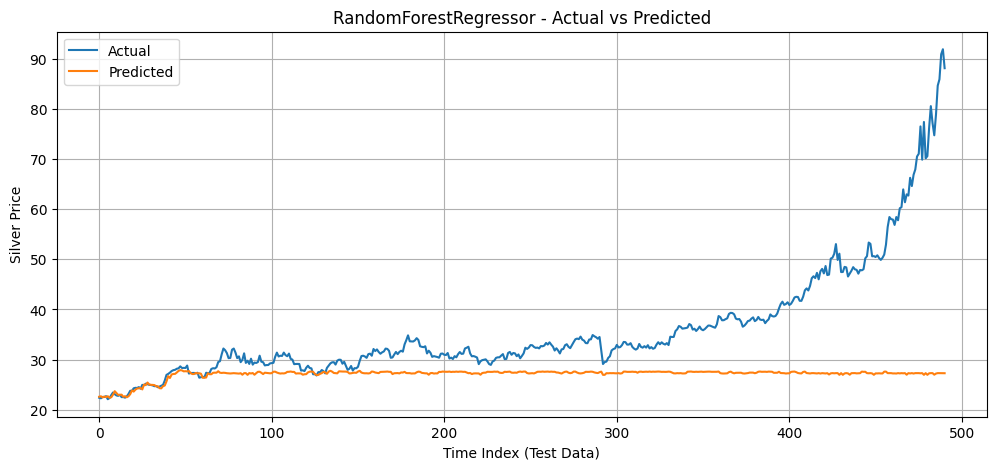

In [157]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.title("RandomForestRegressor - Actual vs Predicted")
plt.xlabel("Time Index (Test Data)")
plt.ylabel("Silver Price")
plt.legend()
plt.grid(True)
plt.show()


กราฟแท่งแสดงค่า Metric

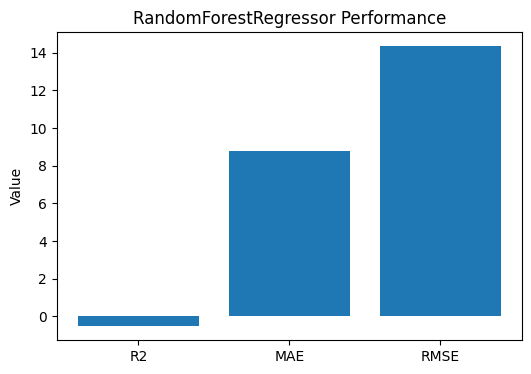

In [158]:
import matplotlib.pyplot as plt

metrics = ["R2", "MAE", "RMSE"]
values = [-0.528353, 8.783399, 14.348218]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.title("RandomForestRegressor Performance")
plt.ylabel("Value")
plt.show()
